In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [5]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

X_train = train.drop(['id', 'PitNextLap'], axis=1).copy()
y_train = train['PitNextLap'].copy()
X_test = test.drop('id', axis=1).copy()
test_ids = test['id'].values

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive class: {y_train.mean():.2%}")

Train: (439140, 14), Test: (188165, 14)
Positive class: 19.90%


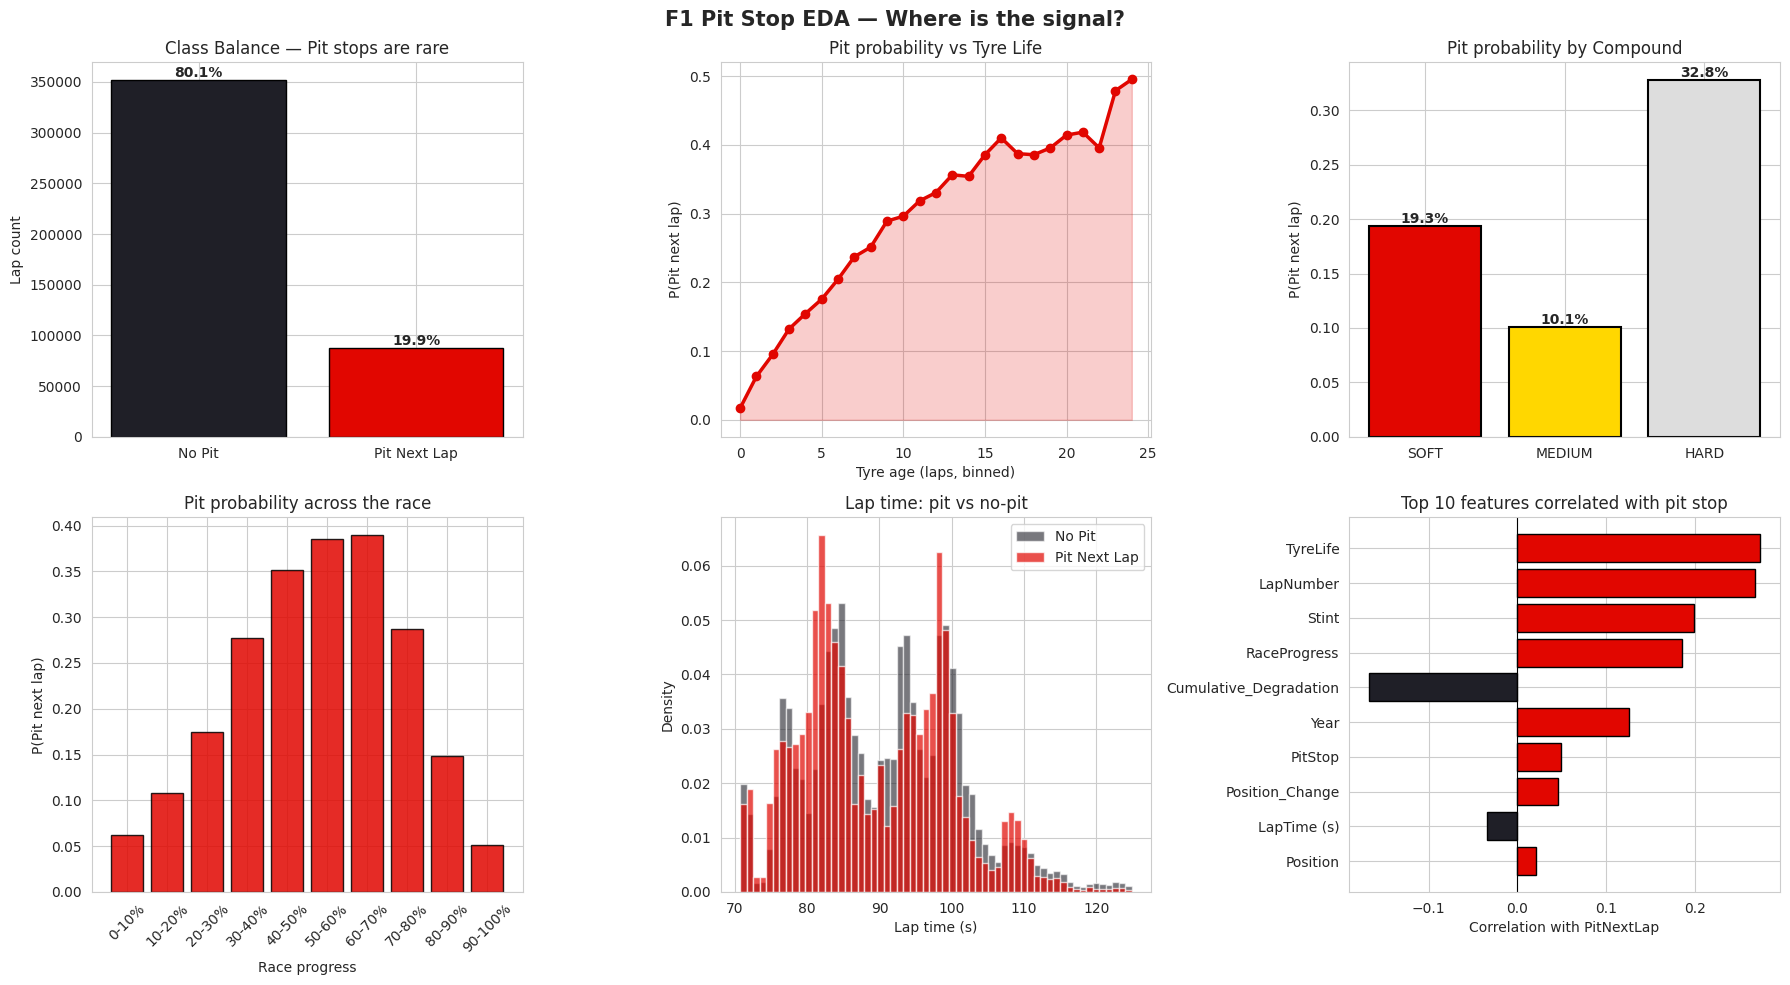

In [6]:
eda = train.copy()
F1_RED = '#E10600'
F1_GREY = '#1F1F27'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('F1 Pit Stop EDA — Where is the signal?', fontsize=15, fontweight='bold')

# 1) Class imbalance
counts = eda['PitNextLap'].value_counts().sort_index()
axes[0, 0].bar(['No Pit', 'Pit Next Lap'], counts.values, color=[F1_GREY, F1_RED], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v, f'{v/counts.sum():.1%}', ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_title('Class Balance — Pit stops are rare')
axes[0, 0].set_ylabel('Lap count')

# 2) Pit rate vs Tyre Life
tyre_bins = pd.cut(eda['TyreLife'], bins=range(0, 51, 2))
pit_by_tyre = eda.groupby(tyre_bins)['PitNextLap'].mean()
axes[0, 1].plot(range(len(pit_by_tyre)), pit_by_tyre.values, color=F1_RED, linewidth=2.5, marker='o')
axes[0, 1].fill_between(range(len(pit_by_tyre)), pit_by_tyre.values, alpha=0.2, color=F1_RED)
axes[0, 1].set_title('Pit probability vs Tyre Life')
axes[0, 1].set_xlabel('Tyre age (laps, binned)')
axes[0, 1].set_ylabel('P(Pit next lap)')

# 3) Pit rate by Compound
compound_order = ['SOFT', 'MEDIUM', 'HARD']
comp_data = eda[eda['Compound'].isin(compound_order)].groupby('Compound')['PitNextLap'].mean().reindex(compound_order)
colors_comp = ['#E10600', '#FFD700', '#DDDDDD']
bars = axes[0, 2].bar(comp_data.index, comp_data.values, color=colors_comp, edgecolor='black', linewidth=1.5)
for bar, v in zip(bars, comp_data.values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, v, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')
axes[0, 2].set_title('Pit probability by Compound')
axes[0, 2].set_ylabel('P(Pit next lap)')

# 4) Pit rate by Race Progress
rp_bins = pd.cut(eda['RaceProgress'], bins=np.linspace(0, 1, 11))
pit_by_rp = eda.groupby(rp_bins)['PitNextLap'].mean()
axes[1, 0].bar(range(len(pit_by_rp)), pit_by_rp.values, color=F1_RED, alpha=0.85, edgecolor='black')
axes[1, 0].set_xticks(range(len(pit_by_rp)))
axes[1, 0].set_xticklabels([f'{i*10}-{(i+1)*10}%' for i in range(len(pit_by_rp))], rotation=45)
axes[1, 0].set_title('Pit probability across the race')
axes[1, 0].set_xlabel('Race progress')
axes[1, 0].set_ylabel('P(Pit next lap)')

# 5) LapTime distribution: pit vs no-pit
laptime_clip = eda[eda['LapTime (s)'].between(eda['LapTime (s)'].quantile(0.01), eda['LapTime (s)'].quantile(0.99))]
axes[1, 1].hist(laptime_clip[laptime_clip['PitNextLap']==0]['LapTime (s)'], bins=60, alpha=0.6, label='No Pit', color=F1_GREY, density=True)
axes[1, 1].hist(laptime_clip[laptime_clip['PitNextLap']==1]['LapTime (s)'], bins=60, alpha=0.7, label='Pit Next Lap', color=F1_RED, density=True)
axes[1, 1].set_title('Lap time: pit vs no-pit')
axes[1, 1].set_xlabel('Lap time (s)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

# 6) Top correlations with target
numeric_cols = eda.select_dtypes(include=[np.number]).drop(columns=['id', 'PitNextLap']).columns
corr_with_target = eda[list(numeric_cols) + ['PitNextLap']].corr()['PitNextLap'].drop('PitNextLap').sort_values(key=abs, ascending=False).head(10)
colors_corr = [F1_RED if v > 0 else F1_GREY for v in corr_with_target.values]
axes[1, 2].barh(range(len(corr_with_target)), corr_with_target.values, color=colors_corr, edgecolor='black')
axes[1, 2].set_yticks(range(len(corr_with_target)))
axes[1, 2].set_yticklabels(corr_with_target.index)
axes[1, 2].set_title('Top 10 features correlated with pit stop')
axes[1, 2].set_xlabel('Correlation with PitNextLap')
axes[1, 2].invert_yaxis()
axes[1, 2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [7]:
def engineer_features(df):
    df = df.copy()

    df['TyreLife_Squared'] = df['TyreLife'] ** 2
    df['TyreLife_Log'] = np.log1p(df['TyreLife'])
    df['TyreLife_Bin'] = pd.cut(df['TyreLife'], bins=[0, 10, 20, 30, 50], labels=[0, 1, 2, 3]).astype(float)

    df['Stint_TyreLife_Interaction'] = df['Stint'] * df['TyreLife']
    df['RaceProgress_TyreLife'] = df['RaceProgress'] * df['TyreLife']
    df['LapNumber_TyreLife'] = df['LapNumber'] * df['TyreLife']

    df['Degradation_per_Lap'] = df['Cumulative_Degradation'] / (df['LapNumber'] + 1)
    df['LapTime_Degradation'] = df['LapTime (s)'] * np.abs(df['Cumulative_Degradation'])

    df['Position_Racing'] = np.abs(df['Position_Change'])
    df['Position_TyreLife'] = df['Position'] * df['TyreLife']

    max_laptime = df['LapTime (s)'].max()
    df['LapTime_Ratio'] = df['LapTime (s)'] / (max_laptime + 1e-8) if max_laptime > 0 else 0.5
    df['LapTime_Delta_Abs'] = np.abs(df['LapTime_Delta'])
    df['LapTime_Consistency'] = 1.0 / (1.0 + np.abs(df['LapTime_Delta']))

    df['Early_Race'] = (df['RaceProgress'] < 0.3).astype(float)
    df['Mid_Race'] = ((df['RaceProgress'] >= 0.3) & (df['RaceProgress'] < 0.7)).astype(float)
    df['Late_Race'] = (df['RaceProgress'] >= 0.7).astype(float)

    compound_degradation = {'SOFT': 3, 'MEDIUM': 2, 'HARD': 1}
    df['Compound_DegradationRate'] = df['Compound'].map(compound_degradation).astype(float)
    df['Compound_DegradationRate'].fillna(2, inplace=True)

    df['Pit_Urgency'] = df['TyreLife'] * df['Compound_DegradationRate'] * (1 + df['RaceProgress'])
    df['Stint_Age'] = df['Stint'] + df['TyreLife'] / 30
    df['LapTime_Delta_TyreLife'] = df['LapTime_Delta'] * df['TyreLife']

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)
print(f"Created {X_train_eng.shape[1] - X_train.shape[1]} new features")

Created 20 new features


In [8]:
categorical_cols = ['Driver', 'Compound', 'Race']
X_train_processed = X_train_eng.copy()
X_test_processed = X_test_eng.copy()

for col in categorical_cols:
    target_mean = y_train.groupby(X_train_eng[col]).mean()
    X_train_processed[col + '_Encoded'] = X_train_eng[col].map(target_mean).fillna(y_train.mean())
    X_test_processed[col + '_Encoded'] = X_test_eng[col].map(target_mean).fillna(y_train.mean())

X_train_processed = X_train_processed.drop(categorical_cols, axis=1)
X_test_processed = X_test_processed.drop(categorical_cols, axis=1)

imputer = SimpleImputer(strategy='median')
X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_processed),
    columns=X_train_processed.columns
)
X_test_processed = pd.DataFrame(
    imputer.transform(X_test_processed),
    columns=X_test_processed.columns
)

print(f"Encoding + imputation complete: {X_train_processed.shape}")

Encoding + imputation complete: (439140, 34)


In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Scale weight: {scale_pos_weight:.2f}")

Train: (351312, 34), Val: (87828, 34), Scale weight: 4.03


In [10]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,
    'learning_rate': 0.08,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 0.5,
    'reg_alpha': 0.3,
    'scale_pos_weight': scale_pos_weight,
    'min_child_weight': 5,
    'seed': 42,
    'tree_method': 'hist'
}

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)

xgb_model = xgb.train(
    xgb_params, dtrain, num_boost_round=500,
    evals=[(dval, 'eval')],
    callbacks=[xgb.callback.EarlyStopping(rounds=50, save_best=True)],
    verbose_eval=50
)

y_pred_xgb_train = xgb_model.predict(xgb.DMatrix(X_train_processed))
y_pred_xgb_test = xgb_model.predict(xgb.DMatrix(X_test_processed))
xgb_auc = roc_auc_score(y_train, y_pred_xgb_train)

print(f"XGBoost ROC-AUC: {xgb_auc:.6f}")

[0]	eval-auc:0.91128
[50]	eval-auc:0.93761
[100]	eval-auc:0.94277
[150]	eval-auc:0.94481
[200]	eval-auc:0.94612
[250]	eval-auc:0.94680
[300]	eval-auc:0.94729
[350]	eval-auc:0.94774
[400]	eval-auc:0.94800
[450]	eval-auc:0.94813
[499]	eval-auc:0.94825
XGBoost ROC-AUC: 0.963249


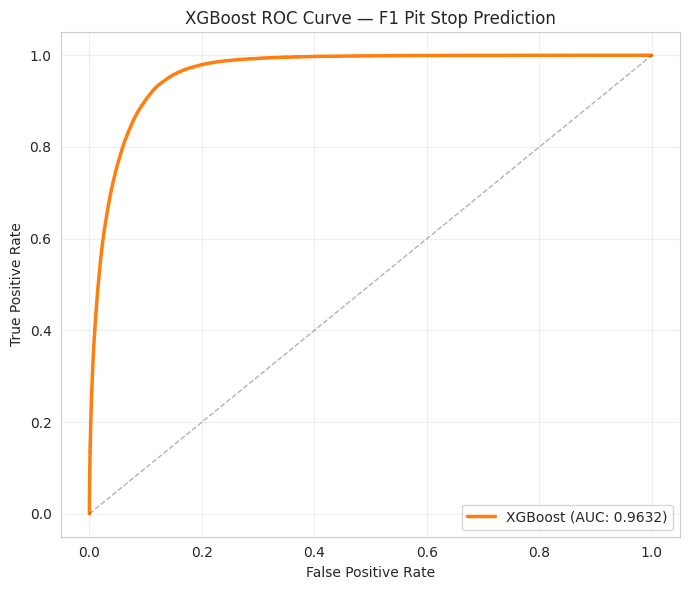

In [11]:
fpr, tpr, _ = roc_curve(y_train, y_pred_xgb_train)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC: {xgb_auc:.4f})', linewidth=2.5, color='#ff7f0e')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve — F1 Pit Stop Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': y_pred_xgb_test
})

submission.to_csv('submission.csv', index=False)

print(f"Submission saved! Shape: {submission.shape}")
print(f"Mean probability: {submission['PitNextLap'].mean():.4f}")
print(submission.head())

Submission saved! Shape: (188165, 2)
Mean probability: 0.2891
       id  PitNextLap
0  439140    0.017394
1  439141    0.014386
2  439142    0.020029
3  439143    0.385030
4  439144    0.948340
